# DCF Valuation Engine — Forward & Reverse

A single, self-contained discounted-cash-flow engine that values a public company **two ways from one model**. The **forward** mode takes growth/margin assumptions and discounts projected unlevered free cash flow to an intrinsic per-share value, with a full WACC build (CAPM cost of equity, after-tax cost of debt, capital-structure weights), a Gordon-growth **and** exit-multiple terminal value, and a WACC × terminal-growth sensitivity grid. The **reverse** mode holds the *current market price* fixed and solves backward for the explicit-period growth rate the market is implicitly pricing in, then compares that implied growth against the company's own historical CAGR. Pulls real fundamentals from Yahoo Finance with a graceful manual-input fallback, real risk-free / ERP inputs from FRED where available, and ends with a side-by-side synthesis: *your view* (intrinsic value + upside/downside) against *the market's view* (implied growth), plus an "expectations gap" verdict. Built so the same `DCFModel` object answers both questions — the reverse DCF is just the forward model solved for a different unknown.

In [14]:
# ============================================================================
# Cell 2 — Installs & imports
# ============================================================================
# Colab usually has pandas/numpy/scipy/matplotlib. yfinance + fredapi are the
# ones we install. pandas-datareader is a fallback path for FRED.
import sys, subprocess

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

_pip("yfinance", "fredapi", "pandas-datareader")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib import cm
from dataclasses import dataclass, field
from typing import Optional, Dict, Tuple, List

from scipy import optimize

import yfinance as yf

# FRED is optional. Without an API key we fall back to sensible defaults.
try:
    from fredapi import Fred
    _HAS_FREDAPI = True
except Exception:
    _HAS_FREDAPI = False

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
})

print("Imports ready. yfinance:", yf.__version__, "| fredapi available:", _HAS_FREDAPI)

Imports ready. yfinance: 0.2.66 | fredapi available: True


## 1. Configuration

Set the target ticker and the macro/valuation inputs. Everything downstream keys off `CONFIG`. The FRED API key is optional — leave it as `""` and the notebook uses well-documented fallback values for the risk-free rate and equity risk premium so it still runs end-to-end.

In [15]:
# ============================================================================
# Cell 4 — Configuration
# ============================================================================
CONFIG = {
    "TICKER": "AAPL",            # <-- change me

    # --- Optional FRED key (https://fred.stlouisfed.org/docs/api/api_key.html)
    "FRED_API_KEY": "",          # leave "" to use fallbacks

    # --- Projection assumptions (FORWARD mode base case) ---
    "PROJECTION_YEARS": 5,
    "BASE_REVENUE_GROWTH": 0.08,   # explicit-period revenue CAGR (base case)
    "TERMINAL_GROWTH": 0.025,      # perpetual growth in Gordon terminal value
    "EXIT_EV_EBITDA": 14.0,        # exit multiple for the alternative TV method

    # --- Margin / conversion assumptions (as % of revenue unless noted) ---
    # If left as None, each is estimated from the company's own history.
    "EBIT_MARGIN": None,           # operating margin
    "TAX_RATE": None,              # effective tax rate
    "DA_PCT_REV": None,            # depreciation & amortization
    "CAPEX_PCT_REV": None,         # capital expenditure
    "NWC_PCT_REV": None,           # incremental net working capital per $ of revenue change

    # --- WACC inputs / fallbacks ---
    "RISK_FREE_FALLBACK": 0.043,   # ~10Y UST if FRED unavailable
    "EQUITY_RISK_PREMIUM": 0.050,  # Damodaran-style mature-market ERP
    "PRETAX_COST_OF_DEBT": 0.050,  # used if not inferable from filings
    "MIN_WACC": 0.06,              # guardrails so reverse-solve stays sane
    "MAX_WACC": 0.18,

    # --- Scenario growth deltas (bull/bear relative to base, in growth pts) ---
    "BULL_DELTA": 0.04,
    "BEAR_DELTA": 0.04,

    # --- Reverse-DCF solver bounds (implied explicit-period growth) ---
    "IMPLIED_GROWTH_MIN": -0.20,
    "IMPLIED_GROWTH_MAX": 0.60,
}

print(f"Target: {CONFIG['TICKER']} | projection horizon: {CONFIG['PROJECTION_YEARS']}y")

Target: AAPL | projection horizon: 5y


## 2. Macro inputs (FRED, with fallback)

Risk-free rate from the 10-Year Treasury (`DGS10`). If FRED isn't reachable or no key is set, we use the documented fallback so the notebook never hard-fails on a network hiccup.

In [16]:
# ============================================================================
# Cell 6 — Risk-free rate (FRED -> fallback)
# ============================================================================
def get_risk_free_rate(cfg) -> Tuple[float, str]:
    """Return (risk_free_decimal, source_label). Never raises."""
    key = cfg.get("FRED_API_KEY", "").strip()

    # Path 1: official fredapi if a key is present
    if key and _HAS_FREDAPI:
        try:
            fred = Fred(api_key=key)
            s = fred.get_series("DGS10").dropna()
            if len(s):
                return float(s.iloc[-1]) / 100.0, "FRED DGS10 (fredapi)"
        except Exception as e:
            print("  fredapi path failed:", e)

    # Path 2: pandas-datareader needs no key for FRED
    try:
        import pandas_datareader.data as web
        from datetime import datetime, timedelta
        start = datetime.today() - timedelta(days=30)
        df = web.DataReader("DGS10", "fred", start)
        s = df["DGS10"].dropna()
        if len(s):
            return float(s.iloc[-1]) / 100.0, "FRED DGS10 (datareader)"
    except Exception as e:
        print("  datareader path failed:", e)

    return float(cfg["RISK_FREE_FALLBACK"]), "fallback constant"

risk_free, rf_source = get_risk_free_rate(CONFIG)
print(f"Risk-free rate: {risk_free:.3%}  (source: {rf_source})")

Risk-free rate: 4.380%  (source: FRED DGS10 (datareader))


## 3. Company fundamentals (Yahoo Finance, with manual fallback)

We pull the income statement, balance sheet, and cash-flow statement plus market data (price, shares, beta). Yahoo's schema shifts over time and line items go missing, so every field is looked up defensively through a helper that tries several aliases and returns `NaN` rather than throwing. If the pull is too thin to model, you can fill `MANUAL_FINANCIALS` in the next cell.

In [17]:
# ============================================================================
# Cell 8 — Pull fundamentals
# ============================================================================
def _row(df: pd.DataFrame, *aliases) -> pd.Series:
    """Find the first matching row (case-insensitive, alias-tolerant)."""
    if df is None or df.empty:
        return pd.Series(dtype="float64")
    idx_lower = {str(i).lower().strip(): i for i in df.index}
    for a in aliases:
        k = a.lower().strip()
        if k in idx_lower:
            return df.loc[idx_lower[k]].astype("float64")
    # loose contains-match
    for a in aliases:
        for low, orig in idx_lower.items():
            if a.lower().strip() in low:
                return df.loc[orig].astype("float64")
    return pd.Series(dtype="float64")

def _latest(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float(s.iloc[0]) if len(s) else np.nan  # yfinance: newest col first

def fetch_fundamentals(ticker: str) -> Dict:
    tk = yf.Ticker(ticker)
    out = {"ticker": ticker, "ok": True, "warnings": []}

    # ---- statements (annual) ----
    inc = getattr(tk, "income_stmt", pd.DataFrame())
    bs  = getattr(tk, "balance_sheet", pd.DataFrame())
    cf  = getattr(tk, "cashflow", pd.DataFrame())

    revenue = _row(inc, "Total Revenue", "TotalRevenue", "Revenue")
    ebit    = _row(inc, "EBIT", "Operating Income", "OperatingIncome")
    pretax  = _row(inc, "Pretax Income", "Income Before Tax")
    taxprov = _row(inc, "Tax Provision", "Income Tax Expense")

    da   = _row(cf, "Depreciation And Amortization", "Depreciation Amortization Depletion",
                "Depreciation")
    capex= _row(cf, "Capital Expenditure", "Capital Expenditures", "Purchase Of PPE")

    total_debt = _row(bs, "Total Debt")
    if total_debt.dropna().empty:
        ltd = _row(bs, "Long Term Debt")
        std = _row(bs, "Current Debt", "Short Term Debt", "Current Debt And Capital Lease Obligation")
        total_debt = ltd.add(std, fill_value=0)
    cash = _row(bs, "Cash And Cash Equivalents", "Cash Cash Equivalents And Short Term Investments",
                "Cash And Cash Equivalents And Short Term Investments")
    curr_assets = _row(bs, "Current Assets", "Total Current Assets")
    curr_liab   = _row(bs, "Current Liabilities", "Total Current Liabilities")

    # ---- history series (oldest..newest) for growth/margins ----
    rev_hist = pd.to_numeric(revenue, errors="coerce").dropna().iloc[::-1]
    out["revenue_history"] = rev_hist

    out["revenue"]   = _latest(revenue)
    out["ebit"]      = _latest(ebit)
    out["pretax"]    = _latest(pretax)
    out["tax_prov"]  = _latest(taxprov)
    out["da"]        = abs(_latest(da)) if not np.isnan(_latest(da)) else np.nan
    out["capex"]     = abs(_latest(capex)) if not np.isnan(_latest(capex)) else np.nan
    out["total_debt"]= _latest(total_debt)
    out["cash"]      = _latest(cash)
    cur_a, cur_l     = _latest(curr_assets), _latest(curr_liab)
    out["nwc"]       = (cur_a - cur_l) if not (np.isnan(cur_a) or np.isnan(cur_l)) else np.nan

    # ---- market data ----
    fast = {}
    try:
        fast = dict(tk.fast_info)
    except Exception:
        pass
    info = {}
    try:
        info = tk.info or {}
    except Exception:
        out["warnings"].append("tk.info unavailable")

    price = fast.get("last_price") or info.get("currentPrice") or info.get("regularMarketPrice")
    if price is None:
        try:
            price = float(tk.history(period="5d")["Close"].dropna().iloc[-1])
        except Exception:
            price = np.nan
    out["price"] = float(price) if price else np.nan

    shares = (fast.get("shares") or info.get("sharesOutstanding")
              or info.get("impliedSharesOutstanding"))
    out["shares"] = float(shares) if shares else np.nan

    beta = info.get("beta")
    out["beta"] = float(beta) if beta else np.nan

    out["name"] = info.get("longName") or info.get("shortName") or ticker
    out["sector"] = info.get("sector", "n/a")

    # interest expense -> infer cost of debt later
    out["interest_expense"] = abs(_latest(_row(inc, "Interest Expense", "Interest Expense Non Operating")))

    # data-quality gate
    essential = ["revenue", "ebit", "price", "shares"]
    missing = [k for k in essential if np.isnan(out.get(k, np.nan))]
    if missing:
        out["ok"] = False
        out["warnings"].append(f"missing essential fields: {missing}")

    return out

try:
    F = fetch_fundamentals(CONFIG["TICKER"])
except Exception as e:
    F = {"ticker": CONFIG["TICKER"], "ok": False, "warnings": [f"fetch raised: {e}"]}

print(f"{F.get('name', CONFIG['TICKER'])}  ({F['ticker']}) | sector: {F.get('sector','n/a')}")
print("Pull OK:", F["ok"], "| warnings:", F["warnings"])
if not np.isnan(F.get("revenue", np.nan)):
    print(f"  Revenue (latest):   {F['revenue']/1e9:,.2f} B")
    print(f"  EBIT (latest):      {F['ebit']/1e9:,.2f} B")
    print(f"  Price / Shares:     {F.get('price', float('nan')):.2f} / {F.get('shares', float('nan'))/1e9:,.3f} B")
    print(f"  Beta:               {F.get('beta', float('nan'))}")

Apple Inc.  (AAPL) | sector: Technology
Pull OK: True | warnings: []
  Revenue (latest):   416.16 B
  EBIT (latest):      133.05 B
  Price / Shares:     281.74 / 14.687 B
  Beta:               1.086


### 3a. Manual fallback (only if the pull failed)

If the cell above reports `Pull OK: False`, fill in the numbers below (in absolute dollars, newest fiscal year) and re-run from here. Leave it untouched if the automatic pull worked.

In [18]:
# ============================================================================
# Cell 10 — Manual fallback (used only if F["ok"] is False)
# ============================================================================
MANUAL_FINANCIALS = {
    # "revenue": 383_285_000_000,
    # "ebit": 114_301_000_000,
    # "tax_rate": 0.15,
    # "da": 11_519_000_000,
    # "capex": 10_959_000_000,
    # "total_debt": 111_088_000_000,
    # "cash": 61_555_000_000,
    # "price": 190.0,
    # "shares": 15_500_000_000,
    # "beta": 1.25,
    # "revenue_history": [274_515e6, 365_817e6, 394_328e6, 383_285e6],
}

if not F.get("ok", False) and MANUAL_FINANCIALS:
    print("Applying manual overrides...")
    for k, v in MANUAL_FINANCIALS.items():
        if k == "revenue_history":
            F[k] = pd.Series(v, dtype="float64")
        elif k == "tax_rate":
            F["tax_prov"] = MANUAL_FINANCIALS["tax_rate"] * MANUAL_FINANCIALS.get("revenue", 0) * 0  # placeholder
            F["_manual_tax_rate"] = v
        else:
            F[k] = v
    # recompute nwc if provided pieces, else leave
    F["ok"] = all(not np.isnan(F.get(x, np.nan)) for x in ["revenue", "ebit", "price", "shares"])
    print("Manual override applied. OK now:", F["ok"])
elif not F.get("ok", False):
    print("Pull failed AND no manual data supplied. Fill MANUAL_FINANCIALS above and re-run.")
else:
    print("Automatic pull was fine; manual fallback skipped.")

Automatic pull was fine; manual fallback skipped.


## 4. Derive base-case drivers from history

Where an assumption in `CONFIG` is `None`, we estimate it from the company's own statements: EBIT margin and D&A/capex/tax as percentages of revenue, and incremental net-working-capital intensity. These become the base-case operating assumptions that both the forward and reverse engines share.

In [19]:
# ============================================================================
# Cell 12 — Derive operating drivers
# ============================================================================
def derive_drivers(F: Dict, cfg: Dict) -> Dict:
    rev = F["revenue"]
    d = {}

    # EBIT margin
    d["ebit_margin"] = cfg["EBIT_MARGIN"] if cfg["EBIT_MARGIN"] is not None else \
        (F["ebit"] / rev if rev else np.nan)

    # Tax rate: prefer explicit provision/pretax; fall back to manual or 21%
    if cfg["TAX_RATE"] is not None:
        d["tax_rate"] = cfg["TAX_RATE"]
    elif F.get("_manual_tax_rate") is not None:
        d["tax_rate"] = F["_manual_tax_rate"]
    elif not np.isnan(F.get("tax_prov", np.nan)) and not np.isnan(F.get("pretax", np.nan)) and F["pretax"]:
        d["tax_rate"] = float(np.clip(F["tax_prov"] / F["pretax"], 0.0, 0.45))
    else:
        d["tax_rate"] = 0.21

    # D&A, capex, NWC as % of revenue
    d["da_pct"]   = cfg["DA_PCT_REV"]   if cfg["DA_PCT_REV"]   is not None else \
        (F["da"]   / rev if (rev and not np.isnan(F.get("da", np.nan)))   else 0.03)
    d["capex_pct"]= cfg["CAPEX_PCT_REV"] if cfg["CAPEX_PCT_REV"] is not None else \
        (F["capex"]/ rev if (rev and not np.isnan(F.get("capex", np.nan))) else 0.04)

    # incremental NWC per $ of revenue change: use NWC/revenue level as a proxy
    if cfg["NWC_PCT_REV"] is not None:
        d["nwc_pct"] = cfg["NWC_PCT_REV"]
    elif not np.isnan(F.get("nwc", np.nan)) and rev:
        d["nwc_pct"] = float(np.clip(F["nwc"] / rev, -0.30, 0.40))
    else:
        d["nwc_pct"] = 0.0

    # historical revenue CAGR (for the reverse-DCF comparison later)
    rh = F.get("revenue_history", pd.Series(dtype="float64"))
    rh = pd.to_numeric(rh, errors="coerce").dropna()
    if len(rh) >= 2 and rh.iloc[0] > 0:
        yrs = len(rh) - 1
        d["hist_rev_cagr"] = (rh.iloc[-1] / rh.iloc[0]) ** (1 / yrs) - 1
    else:
        d["hist_rev_cagr"] = np.nan

    return d

DRV = derive_drivers(F, CONFIG)

drv_tbl = pd.DataFrame({
    "Driver": ["EBIT margin", "Tax rate", "D&A % rev", "Capex % rev",
               "NWC % rev (level)", "Historical revenue CAGR"],
    "Value": [DRV["ebit_margin"], DRV["tax_rate"], DRV["da_pct"],
              DRV["capex_pct"], DRV["nwc_pct"], DRV["hist_rev_cagr"]],
})
drv_tbl["Value"] = drv_tbl["Value"].map(lambda x: f"{x:.2%}" if pd.notna(x) else "n/a")
print(drv_tbl.to_string(index=False))

                 Driver  Value
            EBIT margin 31.97%
               Tax rate 15.61%
              D&A % rev  2.81%
            Capex % rev  3.06%
      NWC % rev (level) -4.25%
Historical revenue CAGR  1.81%


## 5. WACC build (CAPM)

Cost of equity via CAPM ($r_f + \beta \cdot \text{ERP}$), after-tax cost of debt (inferred from interest expense where possible, else the config default), weighted by market value of equity and book debt. Results are clipped to the `[MIN_WACC, MAX_WACC]` guardrails so the reverse solver can't be handed a degenerate discount rate.

In [20]:
# ============================================================================
# Cell 14 — WACC
# ============================================================================
def compute_wacc(F: Dict, DRV: Dict, cfg: Dict, risk_free: float) -> Dict:
    beta = F.get("beta")
    if beta is None or np.isnan(beta):
        beta = 1.0  # neutral default
    erp = cfg["EQUITY_RISK_PREMIUM"]

    cost_equity = risk_free + beta * erp

    # cost of debt: interest expense / total debt if sane, else config
    cod_pre = cfg["PRETAX_COST_OF_DEBT"]
    ie, td = F.get("interest_expense", np.nan), F.get("total_debt", np.nan)
    if not np.isnan(ie) and not np.isnan(td) and td > 0:
        implied = ie / td
        if 0.005 < implied < 0.20:
            cod_pre = implied
    cost_debt_at = cod_pre * (1 - DRV["tax_rate"])

    e_val = (F.get("price", np.nan) * F.get("shares", np.nan))
    d_val = F.get("total_debt", np.nan)
    if np.isnan(e_val):
        e_val = 0.0
    if np.isnan(d_val):
        d_val = 0.0
    v = e_val + d_val
    we = e_val / v if v else 1.0
    wd = d_val / v if v else 0.0

    wacc_raw = we * cost_equity + wd * cost_debt_at
    wacc = float(np.clip(wacc_raw, cfg["MIN_WACC"], cfg["MAX_WACC"]))

    return {
        "beta": beta, "erp": erp, "cost_equity": cost_equity,
        "cost_debt_pretax": cod_pre, "cost_debt_aftertax": cost_debt_at,
        "weight_equity": we, "weight_debt": wd,
        "wacc_raw": wacc_raw, "wacc": wacc,
        "equity_value_mkt": e_val, "debt_value": d_val,
    }

W = compute_wacc(F, DRV, CONFIG, risk_free)

wacc_tbl = pd.DataFrame({
    "Component": ["Risk-free", "Beta", "Equity risk premium", "Cost of equity",
                  "Pre-tax cost of debt", "After-tax cost of debt",
                  "Weight equity", "Weight debt", "WACC (raw)", "WACC (used)"],
    "Value": [risk_free, W["beta"], W["erp"], W["cost_equity"],
              W["cost_debt_pretax"], W["cost_debt_aftertax"],
              W["weight_equity"], W["weight_debt"], W["wacc_raw"], W["wacc"]],
})
def _fmt(r):
    return f"{r:.3f}" if r > 3 else f"{r:.2%}"
wacc_tbl["Value"] = wacc_tbl["Value"].map(_fmt)
print(wacc_tbl.to_string(index=False))
if abs(W["wacc_raw"] - W["wacc"]) > 1e-9:
    print(f"\n  note: raw WACC {W['wacc_raw']:.2%} was clipped to {W['wacc']:.2%} by guardrails.")

             Component   Value
             Risk-free   4.38%
                  Beta 108.60%
   Equity risk premium   5.00%
        Cost of equity   9.81%
  Pre-tax cost of debt   3.99%
After-tax cost of debt   3.36%
         Weight equity  97.67%
           Weight debt   2.33%
            WACC (raw)   9.66%
           WACC (used)   9.66%


## 6. The core engine: `DCFModel`

One class holds the financial state, drivers, and WACC. Its central method `intrinsic_value_per_share(growth)` projects unlevered FCF over the explicit horizon, computes a terminal value, discounts everything, bridges enterprise value to equity value (less net debt), and divides by shares.

**This is the pivot of the whole notebook.** Forward valuation calls this method with an assumed growth rate. Reverse valuation wraps a root-finder around the *same* method to solve for the growth rate that makes the output equal the market price. Forward and reverse are not two models — they are one model queried for two different unknowns.

In [21]:
# ============================================================================
# Cell 16 — DCFModel (shared forward/reverse engine)
# ============================================================================
@dataclass
class DCFModel:
    revenue0: float
    shares: float
    net_debt: float
    wacc: float
    ebit_margin: float
    tax_rate: float
    da_pct: float
    capex_pct: float
    nwc_pct: float
    years: int = 5
    terminal_growth: float = 0.025
    exit_ev_ebitda: float = 14.0

    def project_fcf(self, growth: float) -> pd.DataFrame:
        """Build the explicit-period unlevered FCF schedule for a given growth."""
        rows = []
        rev_prev = self.revenue0
        for yr in range(1, self.years + 1):
            rev = rev_prev * (1 + growth)
            ebit = rev * self.ebit_margin
            nopat = ebit * (1 - self.tax_rate)
            da = rev * self.da_pct
            capex = rev * self.capex_pct
            d_nwc = (rev - rev_prev) * self.nwc_pct  # incremental NWC
            fcf = nopat + da - capex - d_nwc
            disc = (1 + self.wacc) ** yr
            rows.append({
                "Year": yr, "Revenue": rev, "EBIT": ebit, "NOPAT": nopat,
                "D&A": da, "Capex": capex, "ΔNWC": d_nwc, "FCF": fcf,
                "DiscFactor": 1 / disc, "PV_FCF": fcf / disc,
            })
            rev_prev = rev
        return pd.DataFrame(rows)

    def terminal_value(self, sched: pd.DataFrame, method: str = "gordon") -> float:
        last = sched.iloc[-1]
        if method == "gordon":
            fcf_next = last["FCF"] * (1 + self.terminal_growth)
            denom = self.wacc - self.terminal_growth
            if denom <= 0:
                return np.nan
            return fcf_next / denom
        elif method == "exit":
            # exit multiple applied to terminal-year EBITDA proxy (EBIT + D&A)
            ebitda_T = last["EBIT"] + last["D&A"]
            return self.exit_ev_ebitda * ebitda_T
        raise ValueError("method must be 'gordon' or 'exit'")

    def enterprise_value(self, growth: float, tv_method: str = "gordon") -> Tuple[float, pd.DataFrame, float]:
        sched = self.project_fcf(growth)
        tv = self.terminal_value(sched, tv_method)
        pv_tv = tv / ((1 + self.wacc) ** self.years) if not np.isnan(tv) else np.nan
        ev = sched["PV_FCF"].sum() + (pv_tv if not np.isnan(pv_tv) else 0.0)
        return ev, sched, pv_tv

    def intrinsic_value_per_share(self, growth: float, tv_method: str = "gordon") -> float:
        ev, _, _ = self.enterprise_value(growth, tv_method)
        equity_value = ev - self.net_debt
        if self.shares <= 0 or np.isnan(self.shares):
            return np.nan
        return equity_value / self.shares

    # ---- the reverse direction: solve for implied growth given a price ----
    def implied_growth(self, target_price: float, tv_method: str = "gordon",
                       lo: float = -0.20, hi: float = 0.60) -> Optional[float]:
        """Find g such that intrinsic_value_per_share(g) == target_price."""
        f = lambda g: self.intrinsic_value_per_share(g, tv_method) - target_price
        try:
            f_lo, f_hi = f(lo), f(hi)
            if np.isnan(f_lo) or np.isnan(f_hi):
                return None
            if f_lo * f_hi > 0:
                # no sign change in bracket -> price not reachable in range
                return None
            return float(optimize.brentq(f, lo, hi, xtol=1e-6, maxiter=200))
        except Exception:
            return None


# instantiate from the data we assembled
net_debt = (0.0 if np.isnan(F.get("total_debt", np.nan)) else F["total_debt"]) \
         - (0.0 if np.isnan(F.get("cash", np.nan)) else F["cash"])

model = DCFModel(
    revenue0=F["revenue"],
    shares=F["shares"],
    net_debt=net_debt,
    wacc=W["wacc"],
    ebit_margin=DRV["ebit_margin"],
    tax_rate=DRV["tax_rate"],
    da_pct=DRV["da_pct"],
    capex_pct=DRV["capex_pct"],
    nwc_pct=DRV["nwc_pct"],
    years=CONFIG["PROJECTION_YEARS"],
    terminal_growth=CONFIG["TERMINAL_GROWTH"],
    exit_ev_ebitda=CONFIG["EXIT_EV_EBITDA"],
)

print("DCFModel ready.")
print(f"  revenue0={model.revenue0/1e9:,.2f}B | shares={model.shares/1e9:,.3f}B "
      f"| net_debt={model.net_debt/1e9:,.2f}B | WACC={model.wacc:.2%}")

DCFModel ready.
  revenue0=416.16B | shares=14.687B | net_debt=62.72B | WACC=9.66%


## 7. FORWARD valuation — base / bull / bear

Run the engine forward under three growth scenarios, using both terminal-value methods. The base-case FCF schedule is shown in full so every projected line item is auditable.

In [22]:
# ============================================================================
# Cell 18 — Forward valuation across scenarios
# ============================================================================
base_g = CONFIG["BASE_REVENUE_GROWTH"]
scenarios = {
    "Bear": base_g - CONFIG["BEAR_DELTA"],
    "Base": base_g,
    "Bull": base_g + CONFIG["BULL_DELTA"],
}

rows = []
for name, g in scenarios.items():
    for tv in ["gordon", "exit"]:
        v = model.intrinsic_value_per_share(g, tv)
        rows.append({"Scenario": name, "Growth": g, "TV method": tv, "Value/Share": v})
fwd = pd.DataFrame(rows)

price = F.get("price", np.nan)
fwd["Upside vs price"] = fwd["Value/Share"] / price - 1 if price and not np.isnan(price) else np.nan

fwd_disp = fwd.copy()
fwd_disp["Growth"] = fwd_disp["Growth"].map("{:.1%}".format)
fwd_disp["Value/Share"] = fwd_disp["Value/Share"].map(lambda x: f"${x:,.2f}" if pd.notna(x) else "n/a")
fwd_disp["Upside vs price"] = fwd_disp["Upside vs price"].map(lambda x: f"{x:+.1%}" if pd.notna(x) else "n/a")
print(f"Current market price: ${price:,.2f}\n" if pd.notna(price) else "Current price unavailable\n")
print(fwd_disp.to_string(index=False))

# full base-case schedule
ev_base, sched_base, pv_tv_base = model.enterprise_value(base_g, "gordon")
sched_show = sched_base.copy()
for c in ["Revenue", "EBIT", "NOPAT", "D&A", "Capex", "ΔNWC", "FCF", "PV_FCF"]:
    sched_show[c] = sched_show[c].map(lambda x: f"{x/1e9:,.2f}B")
sched_show["DiscFactor"] = sched_base["DiscFactor"].map("{:.3f}".format)
print("\nBase-case unlevered FCF schedule (Gordon TV):")
print(sched_show.to_string(index=False))
print(f"\n  PV of explicit FCF: {sched_base['PV_FCF'].sum()/1e9:,.2f}B")
print(f"  PV of terminal value: {pv_tv_base/1e9:,.2f}B  "
      f"({pv_tv_base/ev_base:.0%} of EV)")
print(f"  Enterprise value: {ev_base/1e9:,.2f}B")
print(f"  Equity value: {(ev_base - model.net_debt)/1e9:,.2f}B")

Current market price: $281.74

Scenario Growth TV method Value/Share Upside vs price
    Bear   4.0%    gordon     $112.04          -60.2%
    Bear   4.0%      exit     $134.19          -52.4%
    Base   8.0%    gordon     $134.02          -52.4%
    Base   8.0%      exit     $160.19          -43.1%
    Bull  12.0%    gordon     $159.37          -43.4%
    Bull  12.0%      exit     $190.13          -32.5%

Base-case unlevered FCF schedule (Gordon TV):
 Year Revenue    EBIT   NOPAT    D&A  Capex   ΔNWC     FCF DiscFactor  PV_FCF
    1 449.45B 143.69B 121.26B 12.63B 13.73B -1.41B 121.58B      0.912 110.87B
    2 485.41B 155.19B 130.96B 13.64B 14.83B -1.53B 131.31B      0.832 109.19B
    3 524.24B 167.60B 141.44B 14.74B 16.02B -1.65B 141.81B      0.758 107.54B
    4 566.18B 181.01B 152.76B 15.91B 17.30B -1.78B 153.15B      0.692 105.91B
    5 611.48B 195.49B 164.98B 17.19B 18.68B -1.92B 165.41B      0.631 104.31B

  PV of explicit FCF: 537.82B
  PV of terminal value: 1,493.24B  (74% of EV

### 7a. Sensitivity grid — WACC × terminal growth

The classic two-way data table. Each cell is the intrinsic value per share at that WACC / terminal-growth pair (base-case explicit growth, Gordon TV). The current price is marked for reference so you can read off the implied "fair" corner of the grid.

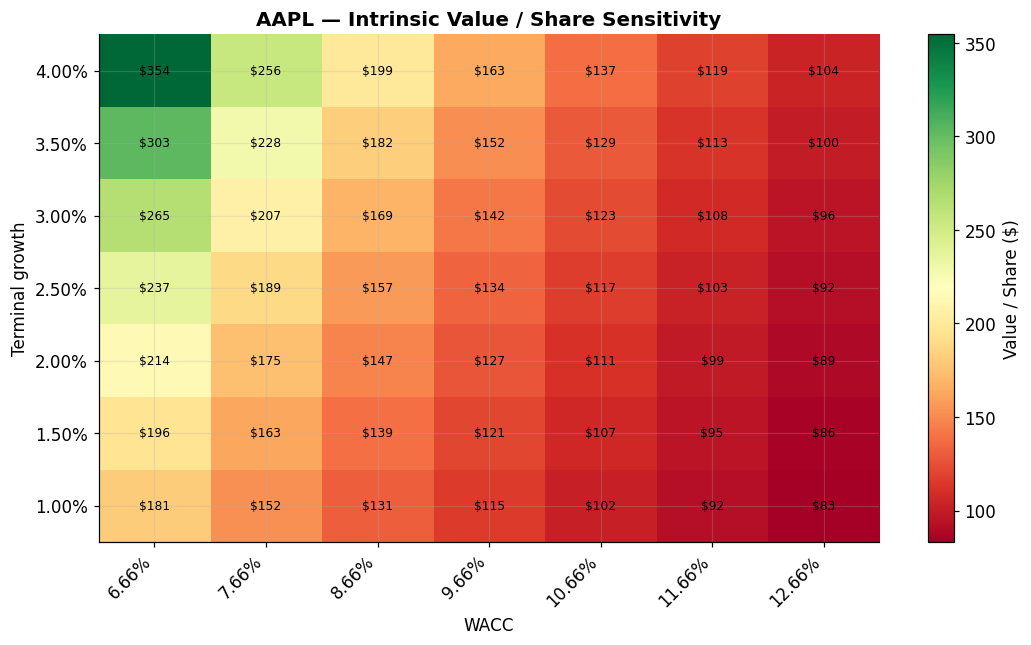

Reference: current price $281.74. Green cells = intrinsic value above current price (undervalued under those inputs).


In [23]:
# ============================================================================
# Cell 20 — Sensitivity heatmap (WACC x terminal growth)
# ============================================================================
wacc_axis = np.round(np.linspace(max(CONFIG["MIN_WACC"], model.wacc - 0.03),
                                 min(CONFIG["MAX_WACC"], model.wacc + 0.03), 7), 4)
tg_axis = np.round(np.linspace(max(0.0, model.terminal_growth - 0.015),
                               model.terminal_growth + 0.015, 7), 4)

grid = np.full((len(tg_axis), len(wacc_axis)), np.nan)
for i, tg in enumerate(tg_axis):
    for j, wc in enumerate(wacc_axis):
        m = DCFModel(**{**model.__dict__, "wacc": float(wc), "terminal_growth": float(tg)})
        grid[i, j] = m.intrinsic_value_per_share(base_g, "gordon")

grid_df = pd.DataFrame(grid, index=[f"{t:.2%}" for t in tg_axis],
                       columns=[f"{w:.2%}" for w in wacc_axis])

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(grid, cmap="RdYlGn", aspect="auto", origin="lower")
ax.set_xticks(range(len(wacc_axis))); ax.set_xticklabels(grid_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(tg_axis)));   ax.set_yticklabels(grid_df.index)
ax.set_xlabel("WACC"); ax.set_ylabel("Terminal growth")
ax.set_title(f"{F['ticker']} — Intrinsic Value / Share Sensitivity")
for i in range(len(tg_axis)):
    for j in range(len(wacc_axis)):
        val = grid[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"${val:,.0f}", ha="center", va="center", fontsize=8,
                    color="black")
cbar = fig.colorbar(im, ax=ax); cbar.set_label("Value / Share ($)")
plt.tight_layout(); plt.show()

if pd.notna(price):
    print(f"Reference: current price ${price:,.2f}. "
          "Green cells = intrinsic value above current price (undervalued under those inputs).")

## 8. REVERSE valuation — what is the market pricing in?

Now invert the engine. Hold WACC, margins, and terminal assumptions fixed; hold the **market price** fixed; solve for the explicit-period growth rate that makes the model output equal the price. That number is the market's implied expectation. We then compare it to the company's own historical revenue CAGR — the heart of the expectations-investing question: *is the market's assumption realistic?*

In [24]:
# ============================================================================
# Cell 22 — Reverse DCF: solve for market-implied growth
# ============================================================================
implied = {}
if pd.notna(price):
    for tv in ["gordon", "exit"]:
        implied[tv] = model.implied_growth(
            price, tv,
            lo=CONFIG["IMPLIED_GROWTH_MIN"], hi=CONFIG["IMPLIED_GROWTH_MAX"]
        )
else:
    print("No market price — reverse DCF skipped.")

hist_cagr = DRV.get("hist_rev_cagr", np.nan)

if implied:
    print(f"Market price: ${price:,.2f}\n")
    for tv, g in implied.items():
        if g is None:
            print(f"  [{tv:>6}] implied growth: not solvable in "
                  f"[{CONFIG['IMPLIED_GROWTH_MIN']:.0%}, {CONFIG['IMPLIED_GROWTH_MAX']:.0%}] "
                  "(price outside model's reachable range)")
        else:
            print(f"  [{tv:>6}] implied explicit-period growth: {g:.2%}")
    if pd.notna(hist_cagr):
        print(f"\n  Company's historical revenue CAGR: {hist_cagr:.2%}")
        g_ref = implied.get("gordon")
        if g_ref is not None:
            gap = g_ref - hist_cagr
            verdict = ("the market is pricing in growth ABOVE its history "
                       "(optimistic / priced for acceleration)") if gap > 0.01 else \
                      ("the market is pricing in growth BELOW its history "
                       "(pessimistic / priced for deceleration)") if gap < -0.01 else \
                      ("the market is pricing in growth ROUGHLY IN LINE with its history")
            print(f"  Expectations gap (implied − historical): {gap:+.2%}")
            print(f"  Read: {verdict}.")
    else:
        print("\n  Historical CAGR unavailable — supply revenue_history for the comparison.")

Market price: $281.74

  [gordon] implied explicit-period growth: 26.11%
  [  exit] implied explicit-period growth: 21.69%

  Company's historical revenue CAGR: 1.81%
  Expectations gap (implied − historical): +24.30%
  Read: the market is pricing in growth ABOVE its history (optimistic / priced for acceleration).


### 8a. Price → implied-growth curve

A visual of the inversion: sweep a range of prices through the reverse solver and plot the growth each price implies. The current price and the company's historical CAGR are marked, so the "expectations gap" is readable at a glance.

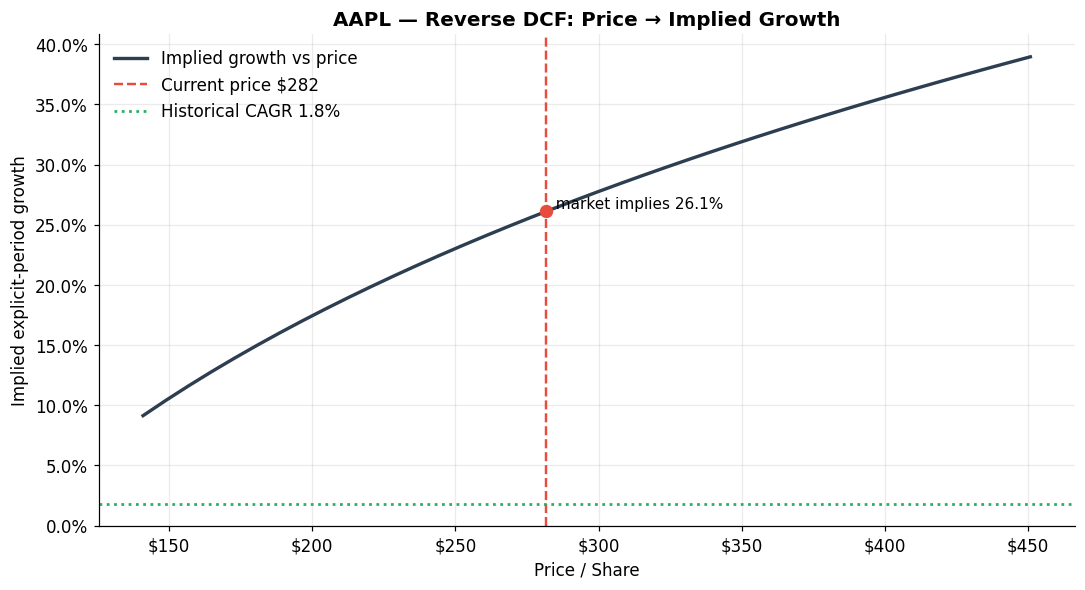

In [25]:
# ============================================================================
# Cell 24 — Price vs implied-growth curve
# ============================================================================
if pd.notna(price):
    lo_p, hi_p = price * 0.5, price * 1.6
    price_grid = np.linspace(lo_p, hi_p, 40)
    implied_curve = [model.implied_growth(p, "gordon",
                     lo=CONFIG["IMPLIED_GROWTH_MIN"], hi=CONFIG["IMPLIED_GROWTH_MAX"])
                     for p in price_grid]

    xs = [p for p, g in zip(price_grid, implied_curve) if g is not None]
    ys = [g for g in implied_curve if g is not None]

    if xs:
        fig, ax = plt.subplots()
        ax.plot(xs, ys, lw=2.2, color="#2c3e50", label="Implied growth vs price")
        ax.axvline(price, color="#e74c3c", ls="--", lw=1.6, label=f"Current price ${price:,.0f}")
        if pd.notna(hist_cagr):
            ax.axhline(hist_cagr, color="#27ae60", ls=":", lw=1.8,
                       label=f"Historical CAGR {hist_cagr:.1%}")
        g_now = model.implied_growth(price, "gordon",
                  lo=CONFIG["IMPLIED_GROWTH_MIN"], hi=CONFIG["IMPLIED_GROWTH_MAX"])
        if g_now is not None:
            ax.scatter([price], [g_now], color="#e74c3c", zorder=5, s=60)
            ax.annotate(f"  market implies {g_now:.1%}", (price, g_now),
                        fontsize=10, va="bottom")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
        ax.set_xlabel("Price / Share"); ax.set_ylabel("Implied explicit-period growth")
        ax.set_title(f"{F['ticker']} — Reverse DCF: Price → Implied Growth")
        ax.legend(frameon=False)
        plt.tight_layout(); plt.show()
    else:
        print("Implied-growth curve empty across the swept price range.")

## 9. Synthesis — *your view* vs *the market's view*

The payoff. One chart and one table put the forward and reverse readings side by side:

- **Your view** (forward): intrinsic value under bear/base/bull, versus the current price — a football-field-style range.
- **The market's view** (reverse): the growth rate baked into today's price, versus what the company has historically delivered.

Together they frame valuation as a debate rather than a single number.

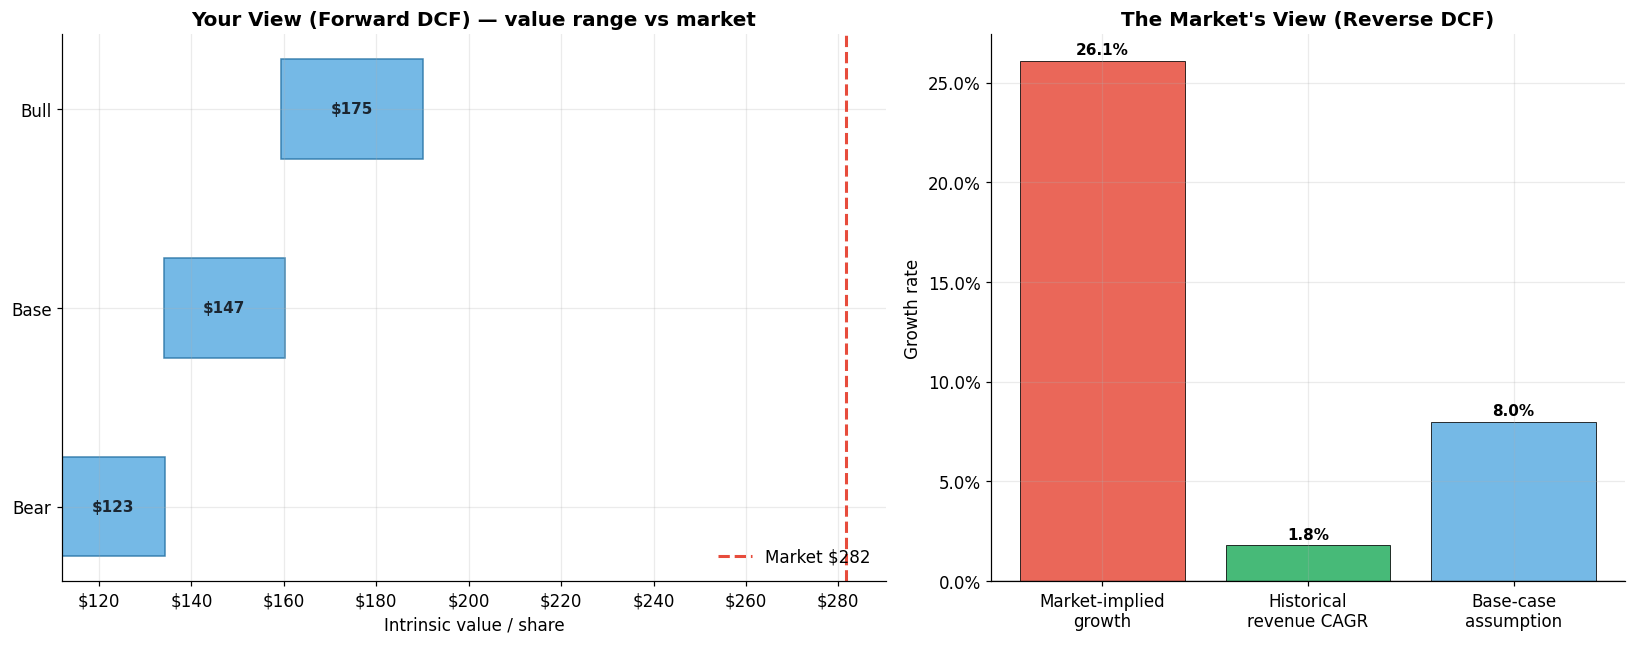

  VALUATION SUMMARY — Apple Inc. (AAPL)
  Current price:                $281.74
  Base-case intrinsic value:    $134.02
  Forward signal:               -52.4% (OVERvalued vs price, base case)
  Market-implied growth:        26.11%
  Historical revenue CAGR:      1.81%
  Expectations gap:             +24.30% (market optimistic)
  Forward and reverse agree when intrinsic value > price AND
  implied growth < what you believe achievable. Divergence = the debate.


In [26]:
# ============================================================================
# Cell 26 — Synthesis: football field + expectations verdict
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6),
                               gridspec_kw={"width_ratios": [1.3, 1]})

# ---- (left) football field of forward values ----
labels, lows, highs, mids = [], [], [], []
for name in ["Bear", "Base", "Bull"]:
    sub = fwd[fwd["Scenario"] == name]["Value/Share"].dropna()
    if len(sub):
        labels.append(name)
        lows.append(sub.min()); highs.append(sub.max()); mids.append(sub.mean())

y = np.arange(len(labels))
for i in range(len(labels)):
    ax1.barh(y[i], highs[i] - lows[i], left=lows[i], height=0.5,
             color="#5DADE2", edgecolor="#2874A6", alpha=0.85)
    ax1.text(mids[i], y[i], f"${mids[i]:,.0f}", va="center", ha="center",
             fontsize=10, fontweight="bold", color="#1B2631")
ax1.set_yticks(y); ax1.set_yticklabels(labels)
if pd.notna(price):
    ax1.axvline(price, color="#e74c3c", ls="--", lw=2, label=f"Market ${price:,.0f}")
    ax1.legend(frameon=False, loc="lower right")
ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax1.set_xlabel("Intrinsic value / share")
ax1.set_title("Your View (Forward DCF) — value range vs market")

# ---- (right) implied vs historical growth ----
g_imp = implied.get("gordon") if implied else None
bars_lbl, bars_val, bars_col = [], [], []
if g_imp is not None:
    bars_lbl.append("Market-implied\ngrowth"); bars_val.append(g_imp); bars_col.append("#e74c3c")
if pd.notna(hist_cagr):
    bars_lbl.append("Historical\nrevenue CAGR"); bars_val.append(hist_cagr); bars_col.append("#27ae60")
bars_lbl.append("Base-case\nassumption"); bars_val.append(base_g); bars_col.append("#5DADE2")

ax2.bar(bars_lbl, bars_val, color=bars_col, alpha=0.85, edgecolor="black", linewidth=0.6)
for i, v in enumerate(bars_val):
    ax2.text(i, v + 0.003, f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_title("The Market's View (Reverse DCF)")
ax2.set_ylabel("Growth rate")
ax2.axhline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

# ---- verdict table ----
print("=" * 64)
print(f"  VALUATION SUMMARY — {F.get('name', F['ticker'])} ({F['ticker']})")
print("=" * 64)
base_val = fwd[(fwd.Scenario=='Base') & (fwd['TV method']=='gordon')]["Value/Share"].iloc[0]
print(f"  Current price:                ${price:,.2f}" if pd.notna(price) else "  Current price: n/a")
print(f"  Base-case intrinsic value:    ${base_val:,.2f}")
if pd.notna(price):
    up = base_val/price - 1
    print(f"  Forward signal:               {up:+.1%} "
          f"({'UNDERvalued' if up>0 else 'OVERvalued'} vs price, base case)")
if g_imp is not None and pd.notna(hist_cagr):
    gap = g_imp - hist_cagr
    print(f"  Market-implied growth:        {g_imp:.2%}")
    print(f"  Historical revenue CAGR:      {hist_cagr:.2%}")
    print(f"  Expectations gap:             {gap:+.2%} "
          f"({'market optimistic' if gap>0 else 'market cautious'})")
print("=" * 64)
print("  Forward and reverse agree when intrinsic value > price AND")
print("  implied growth < what you believe achievable. Divergence = the debate.")

## 10. What this notebook does — and a resume bullet

**Summary.** This notebook is a single discounted-cash-flow engine that values a public company in two complementary directions. The **forward** path pulls real fundamentals (Yahoo Finance) and macro inputs (FRED), derives base-case operating drivers from the company's own history, builds a CAPM-based WACC, projects unlevered free cash flow over an explicit horizon with both Gordon-growth and exit-multiple terminal values, and produces a scenario range plus a WACC × terminal-growth sensitivity grid. The **reverse** path inverts the identical engine with a numerical root-finder to recover the growth rate the market is implicitly pricing into the current share price, then benchmarks that implied expectation against the company's realized growth. A final synthesis presents *your view* (intrinsic value vs price) against *the market's view* (implied vs historical growth), reframing valuation as an explicit expectations debate. The design point is that forward and reverse are one model solved for two different unknowns — not two separate models.

**Resume-ready bullet:**

> *Built a unified forward-and-reverse DCF valuation engine in Python that ingests live fundamentals (Yahoo Finance) and macro data (FRED), constructs a CAPM-based WACC, and projects unlevered free cash flow with dual terminal-value methods; extended it with a Brent-method root-finder to solve the inverse problem — recovering the market-implied growth rate embedded in a stock's price and benchmarking it against historical performance to quantify the market's expectations gap.*

---
*Notes / honest caveats:* Yahoo Finance fundamentals can be incomplete or revised; the manual-fallback cell exists for that. The reverse DCF returns "not solvable" when the market price lies outside the value range the model can produce within the configured growth bounds — that's expected behavior, not a bug, and usually signals that other assumptions (margins, WACC, horizon) would need to move for the price to be reconciled. As with any DCF, outputs are only as good as the assumptions; the reverse mode exists precisely to make that dependence explicit.